# Exploratory Data Analysis of Alzheimer's Disease Data

## 1. Load Data and Initial Exploration

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('alzheimers_disease_data.csv')

# Display the first 5 rows
print('First 5 rows of the dataset:')
print(df.head())

# Display the data types of each column and check for missing values
print('\nData types of each column:')
print(df.dtypes)

First 5 rows of the dataset:
   PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0       4751   73       0          0               2  22.927749        0   
1       4752   89       0          0               0  26.827681        0   
2       4753   73       0          3               1  17.795882        0   
3       4754   74       1          0               1  33.800817        1   
4       4755   89       0          0               0  20.716974        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  ...  MemoryComplaints  \
0           13.297218          6.327112     1.347214  ...                 0   
1            4.542524          7.619885     0.518767  ...                 0   
2           19.555085          7.844988     1.826335  ...                 0   
3           12.209266          8.428001     7.435604  ...                 0   
4           18.454356          6.310461     0.795498  ...                 0   

   BehavioralProblems       ADL  Confus

## 2. Descriptive Statistics

In [2]:
# Calculate and display descriptive statistics for numerical columns
print('\nDescriptive statistics for numerical columns:')
print(df.describe())


Descriptive statistics for numerical columns:
         PatientID          Age       Gender    Ethnicity  EducationLevel  \
count  2149.000000  2149.000000  2149.000000  2149.000000     2149.000000   
mean   5825.000000    74.908795     0.506282     0.697534        1.286645   
std     620.507185     8.990221     0.500077     0.996128        0.904527   
min    4751.000000    60.000000     0.000000     0.000000        0.000000   
25%    5288.000000    67.000000     0.000000     0.000000        1.000000   
50%    5825.000000    75.000000     1.000000     0.000000        1.000000   
75%    6362.000000    83.000000     1.000000     1.000000        2.000000   
max    6899.000000    90.000000     1.000000     3.000000        3.000000   

               BMI      Smoking  AlcoholConsumption  PhysicalActivity  \
count  2149.000000  2149.000000         2149.000000       2149.000000   
mean     27.655697     0.288506           10.039442          4.920202   
std       7.217438     0.453173         

## 3. Feature Engineering

In [3]:
# Feature Engineering
# Drop confidential columns
df = df.drop(columns=['Diagnosis', 'DoctorInCharge'])

# One-hot encode categorical features
df = pd.get_dummies(df, columns=['Ethnicity', 'Gender'], drop_first=True)

print('\nDataFrame after feature engineering:')
print(df.head())


DataFrame after feature engineering:
   PatientID  Age  EducationLevel        BMI  Smoking  AlcoholConsumption  \
0       4751   73               2  22.927749        0           13.297218   
1       4752   89               0  26.827681        0            4.542524   
2       4753   73               1  17.795882        0           19.555085   
3       4754   74               1  33.800817        1           12.209266   
4       4755   89               0  20.716974        0           18.454356   

   PhysicalActivity  DietQuality  SleepQuality  FamilyHistoryAlzheimers  ...  \
0          6.327112     1.347214      9.025679                        0  ...   
1          7.619885     0.518767      7.151293                        0  ...   
2          7.844988     1.826335      9.673574                        1  ...   
3          8.428001     7.435604      8.392554                        0  ...   
4          6.310461     0.795498      5.597238                        0  ...   

        ADL  Confu

## 4. Time-Series Plot of Memory Complaints

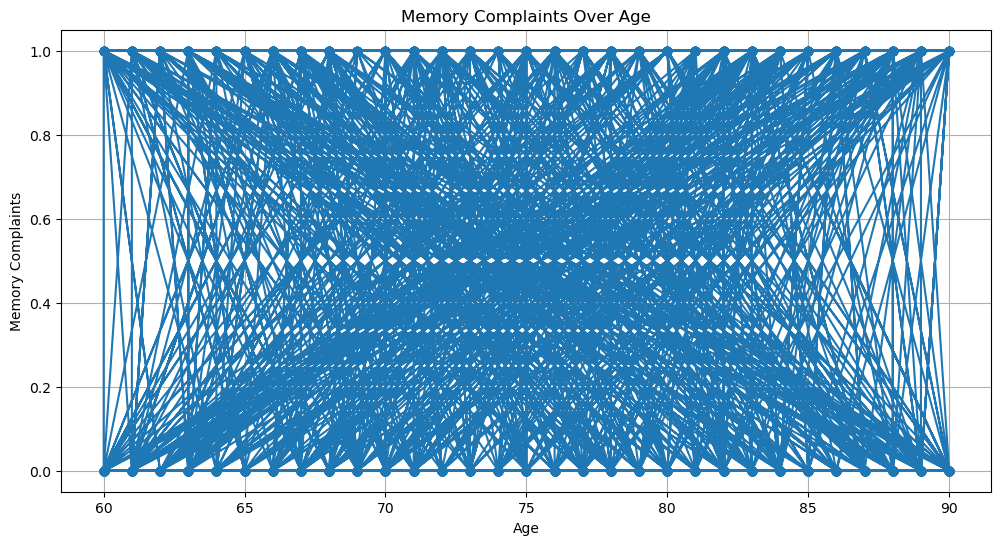

In [4]:
# Time-Series Plot of MemoryComplaints over Age
plt.figure(figsize=(12, 6))
plt.plot(df['Age'], df['MemoryComplaints'], marker='o', linestyle='-')
plt.title('Memory Complaints Over Age')
plt.xlabel('Age')
plt.ylabel('Memory Complaints')
plt.grid(True)
plt.show()

## 5. Top Features Correlated with Forgetfulness


Top 3 features correlated with Forgetfulness:
BMI               0.071131
Disorientation    0.032013
Hypertension      0.029931
Name: Forgetfulness, dtype: float64


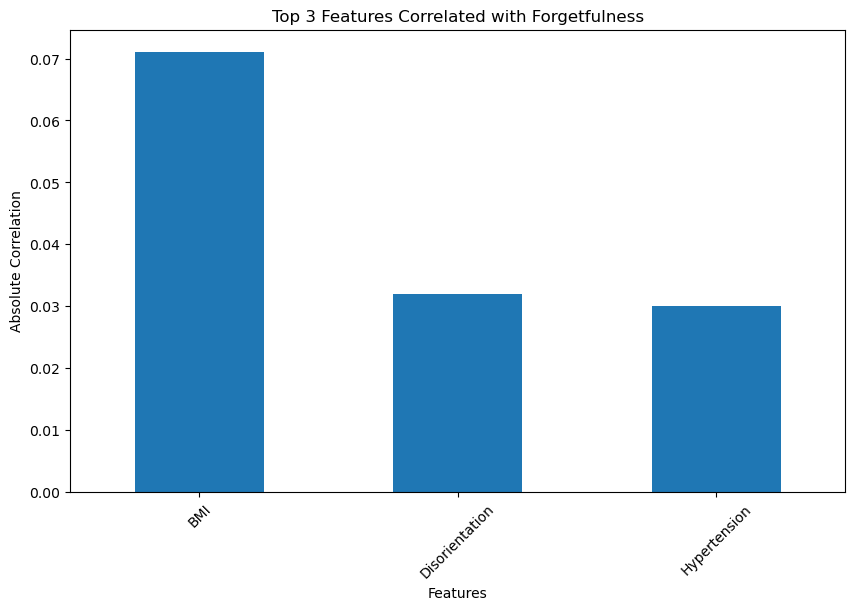

In [5]:
# Top 3 Features Bar Chart
# Calculate the correlation with 'Forgetfulness'
correlation_matrix = df.corr()
forgetfulness_corr = correlation_matrix['Forgetfulness'].abs().sort_values(ascending=False)

# Get the top 3 features (excluding 'Forgetfulness' itself)
top_3_features = forgetfulness_corr[1:4]

print('\nTop 3 features correlated with Forgetfulness:')
print(top_3_features)

# Create a bar chart
plt.figure(figsize=(10, 6))
top_3_features.plot(kind='bar')
plt.title('Top 3 Features Correlated with Forgetfulness')
plt.xlabel('Features')
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45)
plt.show()